# Dataset Description

Generate a synthetic financial time series using a mean-reverting process:

$$
y_{t+1}
=
y_t
+
\alpha(\mu - y_t)
+
\epsilon_t
$$

where:

$$
\epsilon_t \sim \mathcal{N}(0,\sigma^2)
$$

Use the following settings:

- Long-run mean:

$$
\mu = 100
$$

- Mean reversion strength:

$$
\alpha = 0.03
$$

- Noise standard deviation:

$$
\sigma = 1.5
$$

- Initial value: 95
- Total timesteps: 7000
- Sequence length: 40
- Random seed: 42

---

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
np.random.seed(42)
total_time_steps = 7000
mu = 100
alpha = 0.03
sigma = 1.5
y = [95]

for step in range(total_time_steps -1):
  y_next = y[-1] + alpha*(mu - y[-1]) + np.random.normal(0,sigma)
  y.append(y_next)

# Sequence Construction

Convert the raw financial time series into supervised learning sequences using a sliding window.

Each input sequence should contain:

$$
[y_t, y_{t+1}, \dots, y_{t+39}]
$$

The target should be:

$$
y_{t+40}
$$

Example:

| Input Sequence | Target |
|---|---|
| $[y_0,y_1,\dots,y_{39}]$ | $y_{40}$ |
| $[y_1,y_2,\dots,y_{40}]$ | $y_{41}$ |

---

In [3]:
Sequence_length = 40
X = []
targets = []

In [4]:
for i in range(len(y) - Sequence_length):
  X.append(y[i:i + Sequence_length])
  targets.append(y[i+Sequence_length])

In [5]:
X = np.array(X)
targets = np.array(targets)
X = X.reshape(X.shape[0],X.shape[1],1)
targets = targets.reshape(-1,1)
print("X shape:", X.shape)
print("targets shape:", targets.shape)

X shape: (6960, 40, 1)
targets shape: (6960, 1)


Dataset Preparation

1. Generate the synthetic time series.
2. Create sliding-window sequences.
3. Perform:
   - training split
   - validation split
   - test split

Suggested split proportions:

- 70% training
- 15% validation
- 15% test

4. Convert all arrays into PyTorch tensors.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X,targets,test_size=0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

In [7]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

In [9]:
X_train = X_scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val = X_scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = X_scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_train= y_scaler.fit_transform(y_train)
y_val = y_scaler.transform(y_val)
y_test = y_scaler.transform(y_test)

In [10]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

## LSTM Model Construction

Build a recurrent model using:

- `nn.LSTM`
- `batch_first=True`
- hidden size = 64
- number of recurrent layers = 1

After the LSTM layer, use a fully connected layer to produce the final regression prediction.

In [11]:
class Mean_Reverting_Process_LSTM(nn.Module):
  def __init__(self,input_size, hidden_size, output_size, num_layers):
    super(Mean_Reverting_Process_LSTM,self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size,hidden_size,num_layers, batch_first = True)
    self.fc= nn.Linear(hidden_size, output_size)

  def forward(self,x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
    out, (hnn,cn) = self.lstm(x, (h0,c0))
    out = self.fc(out[:,-1,:])
    return out

In [12]:
model = Mean_Reverting_Process_LSTM(input_size=1, hidden_size=64, output_size= 1,num_layers=1)
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [13]:
epochs = 1000
training_losses = []
validation_losses = []

for epoch in range(epochs):
  model.train()
  y_pred = model(X_train)
  train_loss = loss_func(y_pred,y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  training_losses.append(train_loss.item())

  model.eval()
  with torch.no_grad():
    val_pred = model(X_val)
    val_loss = loss_func(val_pred, y_val)
    validation_losses.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
      print(
          f"Epoch [{epoch+1}/1000], "
          f"Train Loss: {train_loss.item():.4f}, "
          f"Val Loss: {val_loss.item():.4f}")

Epoch [100/1000], Train Loss: 0.1061, Val Loss: 0.0968
Epoch [200/1000], Train Loss: 0.0718, Val Loss: 0.0647
Epoch [300/1000], Train Loss: 0.0626, Val Loss: 0.0560
Epoch [400/1000], Train Loss: 0.0588, Val Loss: 0.0531
Epoch [500/1000], Train Loss: 0.0584, Val Loss: 0.0544
Epoch [600/1000], Train Loss: 0.0576, Val Loss: 0.0531
Epoch [700/1000], Train Loss: 0.0575, Val Loss: 0.0532
Epoch [800/1000], Train Loss: 0.0574, Val Loss: 0.0534
Epoch [900/1000], Train Loss: 0.0578, Val Loss: 0.0536
Epoch [1000/1000], Train Loss: 0.0572, Val Loss: 0.0536


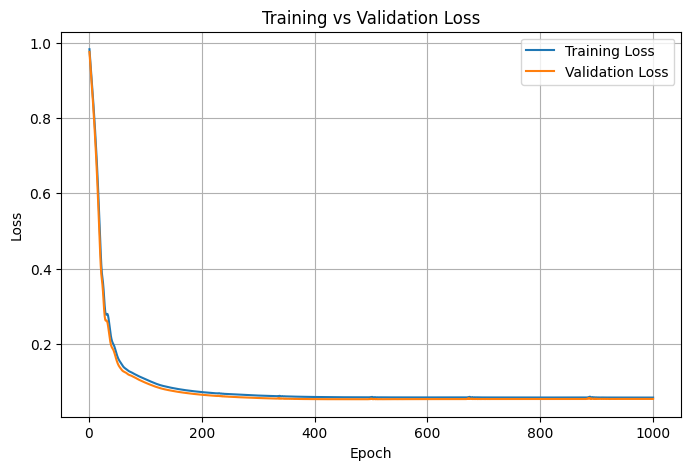

In [15]:
epochs = range(1, len(training_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, training_losses, label="Training Loss")
plt.plot(epochs, validation_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
model.eval()
with torch.no_grad():
  y_pred = model(X_test)
  test_loss = loss_func(y_pred,y_test)
  print(f"Test Loss: {test_loss.item():.4f}")

# Convert tensors to NumPy
y_test_np = y_test.numpy()
y_pred_np = y_pred.numpy()

#Metrics
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)

print(f"Test RMSE: {rmse:.4f}")

Test Loss: 0.0562
Test MSE: 0.0562
Test RMSE: 0.2372
